<a href="https://colab.research.google.com/github/nemiys/Project-3---Airbnb-Dublin-/blob/main/AirbnbDablin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl">

# פרויקט ניתוח נתוני Airbnb דבלין
במחברת זו נבצע ניתוח מעמיק (EDA) על נתוני חיפושים ומגעים בין אורחים למארחים. המטרה היא לזהות דפוסי התנהגות, אחוזי המרה ותובנות עסקיות.

</div>

<div dir="rtl">

## שלב 1: ייבוא ספריות והגדרות תצוגה
בשלב זה נטען את כל הכלים הדרושים לעיבוד הנתונים וויזואליזציה.

</div>

In [ ]:
# ספריות לניהול ועיבוד טבלאות נתונים
import pandas as pd
import numpy as np

# ספריות ליצירת גרפים וויזואליזציות
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרות תצוגה
%matplotlib inline
pd.options.display.float_format = '{:.2f}'.format # הצגת מספרים עם 2 ספרות אחרי הנקודה
sns.set_theme(style="whitegrid") # עיצוב גרפים נקי

print("הספריות נטענו בהצלחה!")

הספריות נטענו בהצלחה!


<div dir="rtl">

## שלב 2: חיבור ל-Google Drive וטעינת הנתונים
כדי לשמור על רציפות העבודה, נחבר את המחברת ישירות ל-Google Drive ונטען את קבצי המקור.

</div>

In [ ]:
import pandas as pd

# הגדרת נתיבי ה-Raw מגיטהאב
path_contacts = 'https://github.com/nemiys/Project-3---Airbnb-Dublin-/raw/refs/heads/main/contacts_fixed.xlsx'
path_searches = 'https://github.com/nemiys/Project-3---Airbnb-Dublin-/raw/refs/heads/main/searches_fixed.xlsx'

try:
    # טעינת הקבצים ישירות מהרשת
    df_contacts = pd.read_excel(path_contacts)
    df_searches = pd.read_excel(path_searches)

    print("--- סטטוס טעינה מ-GitHub ---")
    print(f"טבלת Contacts נטענה: {df_contacts.shape[0]} שורות")
    print(f"טבלת Searches נטענה: {df_searches.shape[0]} שורות")

except Exception as e:
    print(f"שגיאה בטעינת הקבצים מגיטהאב. וודא שהקישורים תקינים. הודעת השגיאה: {e}")

# הצצה לנתוני החיפושים
df_searches.head()

--- סטטוס טעינה מ-GitHub ---
טבלת Contacts נטענה: 7823 שורות
טבלת Searches נטענה: 35737 שורות


,ds,id_user,ds_checkin,ds_checkout,date_check,n_searches,n_nights,stay_category,n_guests_min,n_guests_max,origin_country,filter_price_min,filter_price_max,uses_price_filter,filter_room_types_corrected,uses_room_filter,filter_neighborhoods,search_lead_time,lead_time_category
0,2014-10-01,0000af0a-6f26-4233-9832-27efbfb36148,2014-10-09,2014-10-12,OK,16,3.00,1-3 Nights (Weekend/Short),2,2,IE,0.00,67.00,1,"['Private room', 'Entire home/apt']",1,NaN,8,8-30 Days (Short Term)
1,2014-10-01,0000af0a-6f26-4233-9832-27efbfb36148,2014-10-09,2014-10-19,OK,3,10.00,7-27 Nights (Extended Stay),1,2,IE,0.00,67.00,1,NaN,0,NaN,8,8-30 Days (Short Term)
2,2014-10-01,000cd9d3-e05b-4016-9e09-34a6f8ba2fc5,NaT,NaT,Missing Dates,1,NaN,No Dates Provided,1,1,GB,NaN,NaN,0,NaN,0,NaN,No Date,No Date
3,2014-10-01,000cd9d3-e05b-4016-9e09-34a6f8ba2fc5,2014-11-08,2014-11-10,OK,11,2.00,1-3 Nights (Weekend/Short),1,2,GB,NaN,NaN,0,['Entire home/apt'],1,NaN,38,31-90 Days (Medium Term)
4,2014-10-01,001c04f0-5a94-4ee0-bf5d-3591265256de,NaT,NaT,Missing Dates,1,NaN,No Dates Provided,1,1,IE,NaN,NaN,0,NaN,0,NaN,No Date,No Date


<div dir="rtl">

## שלב 3: בדיקת סוגי נתונים ואיכות המידע (Data Info & Quality)
בשלב זה נוודא שפייתון מזהה נכון את סוגי העמודות (תאריכים כ-Datetime, מספרים כ-Int/Float ומזהים כ-String). כמו כן, נבדוק האם קיימים ערכים חסרים (Missing Values) שעלולים להשפיע על המיזוג.

</div>

In [ ]:
# בדיקת סוגי הנתונים וערכים חסרים בטבלת החיפושים
print("--- מידע על טבלת Searches ---")
print(df_searches.info())

print("\n" + "="*50 + "\n")

# בדיקת סוגי הנתונים וערכים חסרים בטבלת המגעים
print("--- מידע על טבלת Contacts ---")
print(df_contacts.info())

# בדיקת כמות ערכים חסרים בכל עמודה
print("\n--- ערכים חסרים ב-Searches ---")
print(df_searches.isnull().sum())

--- מידע על טבלת Searches ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35737 entries, 0 to 35736
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ds                           35737 non-null  datetime64[ns]
 1   id_user                      35737 non-null  object        
 2   ds_checkin                   23888 non-null  datetime64[ns]
 3   ds_checkout                  23888 non-null  datetime64[ns]
 4   date_check                   35737 non-null  object        
 5   n_searches                   35737 non-null  int64         
 6   n_nights                     23888 non-null  float64       
 7   stay_category                35737 non-null  object        
 8   n_guests_min                 35737 non-null  int64         
 9   n_guests_max                 35737 non-null  int64         
 10  origin_country               35737 non-null  object        
 11  filter_pric

In [ ]:
print("=== DATA QUALITY CHECKS ===")

print("\n1. Guests logic check (min > max):")
print((df_searches['n_guests_min'] > df_searches['n_guests_max']).sum())

print("\n2. Length of stay vs dates mismatch:")
print((df_contacts['length_of_stay'] !=
       (df_contacts['ds_checkout'] - df_contacts['ds_checkin']).dt.days).sum())

print("\n3. Negative reply times:")
print((df_contacts['reply_time_minutes'] < 0).sum())

=== DATA QUALITY CHECKS ===

1. Guests logic check (min > max):
0

2. Length of stay vs dates mismatch:
0

3. Negative reply times:
0


<div dir="rtl">

## 1. ניתוח משפך ההמרה הכללי (The Overall Conversion Funnel)
**מטרה:** להבין את יעילות התהליך בדבלין במהלך חודש אוקטובר – מהחיפוש הראשוני ועד לביצוע הזמנה סגורה.

**הגדרות המדדים:**
* **Search to Contact (Conversion Rate):** אחוז המשתמשים הייחודיים שביצעו לפחות חיפוש אחד ועברו לשלב יצירת קשר עם מארח.
* **Contact to Booking (Close Rate):** אחוז הפניות (Inquiries) שהבשילו לכדי הזמנה מאושרת ומשולמת.

**ממצאים מרכזיים:**
* **המרה לשיחה:** 15.79% - מעיד על עניין גבוה אך סלקטיבי בשוק דבלין.
* **המרה להזמנה:** 32.9% - כשליש מהפניות מסתיימות בעסקה, נתון חיובי המעיד על מלאי רלוונטי.
* **נפח פעילות:** 1,921 הזמנות סגורות במהלך החודש.

</div>

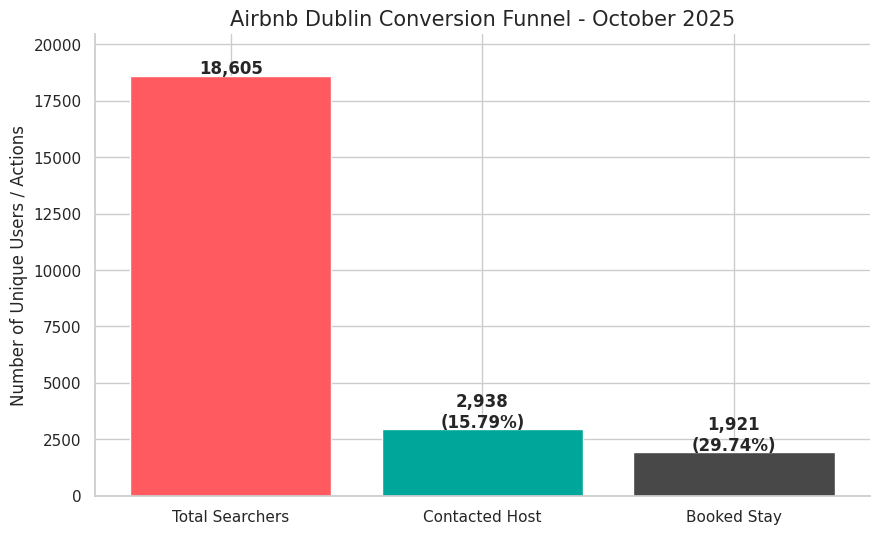

Total Searchers: 18,605
Users who contacted: 2,938 (15.79%)
Total Bookings: 1,921 (Out of all contacts: 29.74%)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. הכנת הנתונים - סינון לחודש אוקטובר בלבד
oct_searches = df_searches[df_searches['ds'].dt.month == 10].copy()
oct_contacts = df_contacts[df_contacts['ts_contact_at'].dt.month == 10].copy()

# 2. חישוב ערכי המשפך (Unique Users)
total_searchers = oct_searches['id_user'].nunique()
total_converters = oct_searches[oct_searches['id_user'].isin(oct_contacts['id_guest'])]['id_user'].nunique()
total_bookings = oct_contacts[oct_contacts['is_booked'] == 1]['id_guest'].count() # ספירת הזמנות סופיות

# חישוב אחוזים
search_to_contact_pct = (total_converters / total_searchers) * 100
contact_to_booking_pct = (total_bookings / len(oct_contacts)) * 100

# 3. יצירת ויזואליזציה - גרף משפך (Funnel Chart)
labels = ['Total Searchers', 'Contacted Host', 'Booked Stay']
values = [total_searchers, total_converters, total_bookings]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#FF5A5F', '#00A699', '#484848'])

# הוספת תוויות טקסט על הברים
plt.text(0, total_searchers + 100, f'{total_searchers:,}', ha='center', fontweight='bold')
plt.text(1, total_converters + 100, f'{total_converters:,}\n({search_to_contact_pct:.2f}%)', ha='center', fontweight='bold')
plt.text(2, total_bookings + 100, f'{total_bookings:,}\n({contact_to_booking_pct:.2f}%)', ha='center', fontweight='bold')

plt.title('Airbnb Dublin Conversion Funnel - October 2025', fontsize=15)
plt.ylabel('Number of Unique Users / Actions')
plt.ylim(0, total_searchers * 1.1)
sns.despine()
plt.show()

# הדפסת סיכום מספרי למעקב
print(f"Total Searchers: {total_searchers:,}")
print(f"Users who contacted: {total_converters:,} ({search_to_contact_pct:.2f}%)")
print(f"Total Bookings: {total_bookings:,} (Out of all contacts: {contact_to_booking_pct:.2f}%)")

<div dir="rtl">

## 1א. ניתוח נפח פעילות גולמי (Volume Analysis - Actions)
**מטרה:** הבנת העומס התפעולי על הפלטפורמה בדבלין. ניתוח זה סופר **פעולות** (Actions) ולא משתמשים ייחודיים.

**הגדרות המדדים:**
* **Total Searches:** סך כל שאילתות החיפוש שבוצעו באוקטובר.
* **Total Contacts:** סך כל הודעות הפנייה הראשוניות שנשלחו למארחים.
* **Total Bookings:** סך כל ההזמנות שנסגרו ואושרו סופית.

**ממצאים מרכזיים:**
* הנתונים מראים את ה"משפך התפעולי": מתוך מאות אלפי חיפושים, נגזרות אלפי פניות, שמובילות לאלפי הזמנות.
* מדד זה קריטי עבור צוותי תמיכה ותפעול כדי להבין את עומס ההודעות שהמארחים בדבלין נדרשים לנהל.

</div>

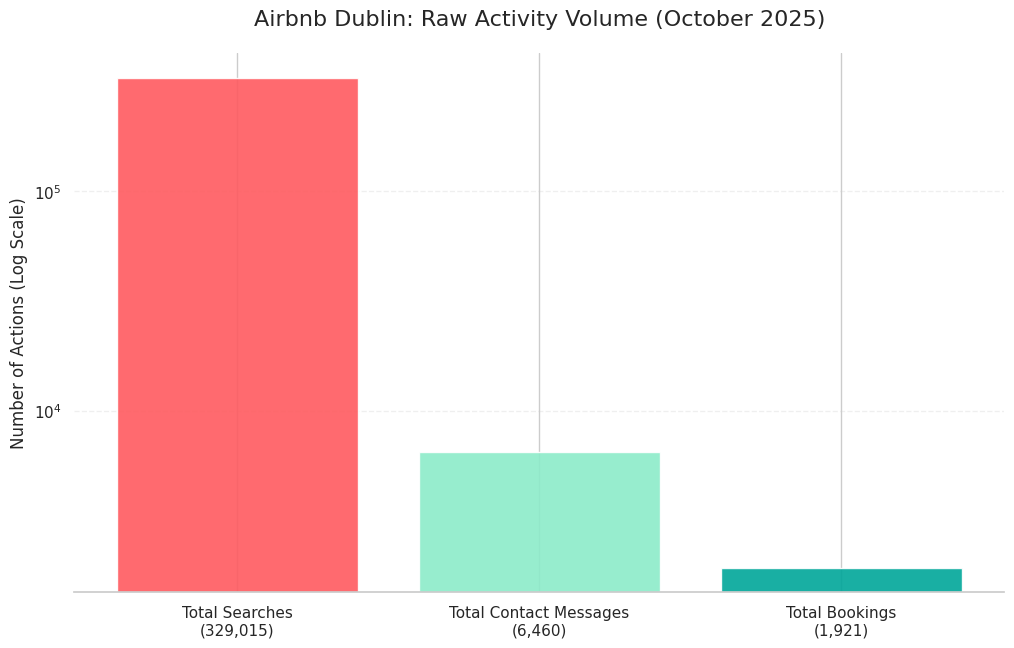

Total Search Actions: 329,015
Total Contact Messages: 6,460
Total Confirmed Bookings: 1,921


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. הכנת הנתונים - סינון גולמי לאוקטובר (ללא אגריגציה)
oct_searches = df_searches[df_searches['ds'].dt.month == 10]
oct_contacts = df_contacts[df_contacts['ts_contact_at'].dt.month == 10]

# 2. חישוב סך הפעולות הגולמי
total_search_actions = oct_searches['n_searches'].sum() # סך החיפושים שבוצעו
total_contact_actions = len(oct_contacts) # סך הפניות הגולמי
total_booking_actions = oct_contacts['is_booked'].sum() # סך ההזמנות הסופיות

# 3. ויזואליזציה - משפך פעולות גולמי
labels = [f'Total Searches\n({total_search_actions:,})',
          f'Total Contact Messages\n({total_contact_actions:,})',
          f'Total Bookings\n({total_booking_actions:,})']
values = [total_search_actions, total_contact_actions, total_booking_actions]

plt.figure(figsize=(12, 7))
colors = ['#FF5A5F', '#8CEBC9', '#00A699'] # צבעי Airbnb
bars = plt.bar(labels, values, color=colors, alpha=0.9)

# עיצוב הגרף
plt.title('Airbnb Dublin: Raw Activity Volume (October 2025)', fontsize=16, pad=20)
plt.ylabel('Number of Actions (Log Scale)', fontsize=12)
plt.yscale('log') # סקאלה לוגריתמית בגלל ההפרש העצום בין חיפושים לבוקינג
sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

print(f"Total Search Actions: {total_search_actions:,}")
print(f"Total Contact Messages: {total_contact_actions:,}")
print(f"Total Confirmed Bookings: {total_booking_actions:,}")

<div dir="rtl">

## 1א. ניתוח נפח פעילות גולמי (Raw Volume Analysis)
**מטרה:** הבנת העומס התפעולי על הפלטפורמה בדבלין לפי כניסות (Sessions) ופעולות.

**הגדרות המדדים:**
* **Total Sessions (Search Table Rows):** סך כל השורות בטבלת החיפושים. כל שורה מייצגת כניסה של משתמש לביצוע שאילתה.
* **Total Contact Messages:** סך כל פניות ההודעה הראשוניות שנשלחו למארחים.
* **Total Bookings:** סך כל ההזמנות שאושרו ונסגרו סופית.

**יחסי המרה (Actions Efficiency):**
* **Session to Contact:** אחוז הכניסות שהובילו לשליחת הודעה.
* **Contact to Booking:** אחוז ההודעות שהבשילו לכדי הזמנה סגורה.

</div>

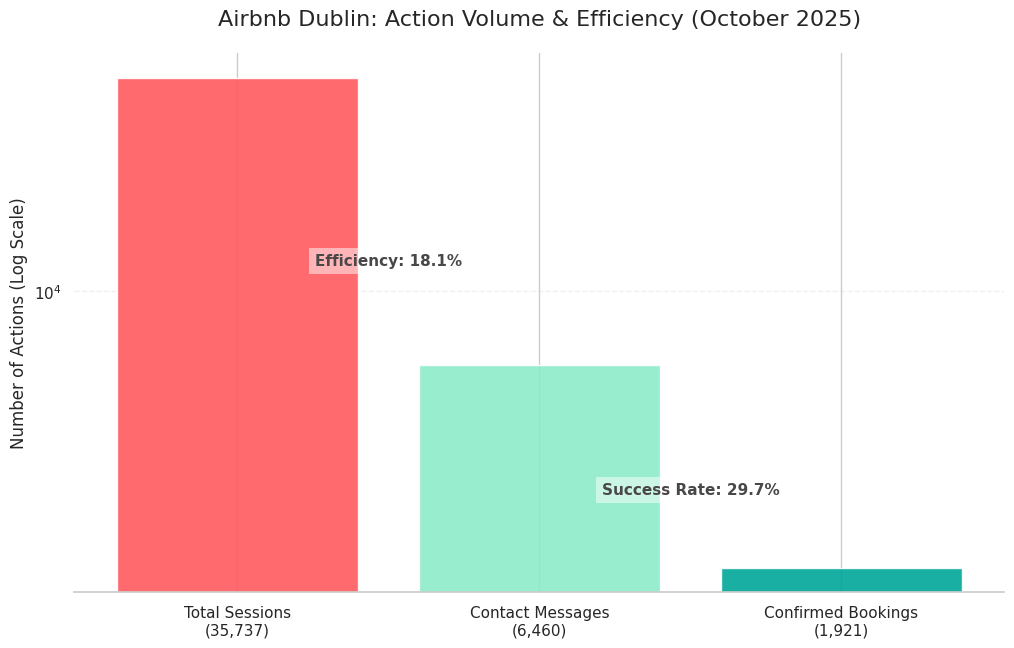

Total Sessions: 35,737
Total Contacts: 6,460 (Rate: 18.08%)
Total Bookings: 1,921 (Rate: 29.74%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. הכנת הנתונים
oct_searches = df_searches[df_searches['ds'].dt.month == 10]
oct_contacts = df_contacts[df_contacts['ts_contact_at'].dt.month == 10]

# 2. חישוב סך הפעולות
total_sessions = len(oct_searches)
total_contacts = len(oct_contacts)
total_bookings = oct_contacts['is_booked'].sum()

# חישוב אחוזי המרה בין השלבים
session_to_contact_rate = (total_contacts / total_sessions) * 100
contact_to_booking_rate = (total_bookings / total_contacts) * 100

# 3. ויזואליזציה
labels = [f'Total Sessions\n({total_sessions:,})',
          f'Contact Messages\n({total_contacts:,})',
          f'Confirmed Bookings\n({total_bookings:,})']
values = [total_sessions, total_contacts, total_bookings]

plt.figure(figsize=(12, 7))
colors = ['#FF5A5F', '#8CEBC9', '#00A699']
bars = plt.bar(labels, values, color=colors, alpha=0.9)

# הוספת תוויות אחוזים בין הברים
plt.text(0.5, total_contacts + 5000, f'Efficiency: {session_to_contact_rate:.1f}%',
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='#484848',
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.text(1.5, total_bookings + 1000, f'Success Rate: {contact_to_booking_rate:.1f}%',
         ha='center', va='bottom', fontsize=11, fontweight='bold', color='#484848',
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.title('Airbnb Dublin: Action Volume & Efficiency (October 2025)', fontsize=16, pad=20)
plt.ylabel('Number of Actions (Log Scale)')
plt.yscale('log')
sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print(f"Total Sessions: {total_sessions:,}")
print(f"Total Contacts: {total_contacts:,} (Rate: {session_to_contact_rate:.2f}%)")
print(f"Total Bookings: {total_bookings:,} (Rate: {contact_to_booking_rate:.2f}%)")

<div dir="rtl">

## 1ב. ניתוח משפך המרה לפי משתמשים ייחודיים (User Funnel)
**מטרה:** הבנת יעילות הפלטפורמה בהמרת "מתעניינים" ל"לקוחות משלמים". ניתוח זה מבצע **אגריגציה** וסופר אנשים ייחודיים בלבד.

**הגדרות המדדים:**
* **Unique Searchers:** מספר האנשים הייחודיים שחיפשו באוקטובר.
* **Unique Contactors:** מספר האנשים הייחודיים שעברו את הסף ושלחו לפחות הודעה אחת.
* **Unique Bookers:** מספר האנשים הייחודיים שביצעו לפחות הזמנה סגורה אחת.

**ממצאים מרכזיים:**
* **Conversion Rate (Search to Contact):** 15.8% - זהו אחוז ההמרה המרכזי של הפלטפורמה.
* **Close Rate (Contact to Booker):** 33.0% - כשליש מהאנשים שיוצרים קשר, בסופו של דבר סוגרים עסקה. זהו מדד חזק המעיד על מלאי איכותי ומארחים משתפי פעולה.

</div>

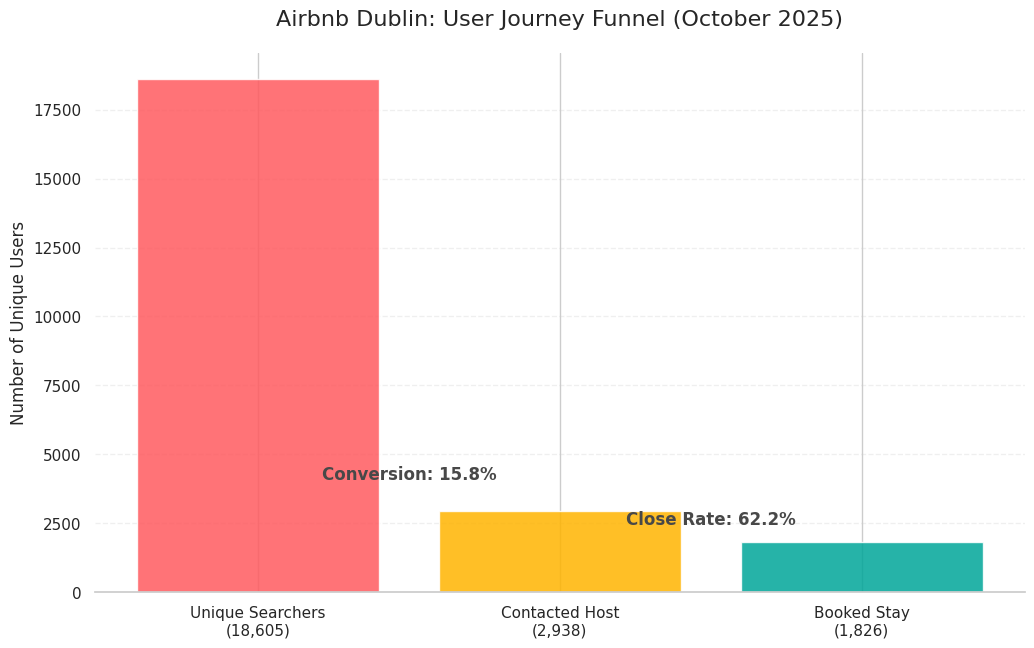

Unique Searchers: 18,605
Unique users who contacted: 2,938 (15.8%)
Unique users who booked: 1,826 (Out of all contactors: 62.2%)


<div dir="rtl">

### 2א. השפעת הדחיפות (Lead Time) על "איכות החיפוש"
**מטרה:** לבחון האם חיפושים המבוצעים סמוך למועד האירוח (Last Minute) הם בעלי כוונת רכישה גבוהה יותר מחיפושים עתידיים.

**שיטת החישוב (הגדרה):**
* **יחידת המדידה:** שורת חיפוש (Search Session). כל כניסה של משתמש וביצוע שאילתה נספרים כאירוע נפרד.
* **המרת שורה (Conversion):** שורת חיפוש נחשבת כ"מומרת" אם המשתמש שביצע אותה שלח לפחות הודעה אחת למארח במהלך חודש אוקטובר.
* **המדד (Conversion Rate %):** אחוז אירועי החיפוש מתוך סך החיפושים בקטגוריה שהובילו לפנייה אקטיבית.

**תובנה עסקית:**
מדד זה משקף את **כוונת הרכישה (Intent)** של המשתמש ברגע החיפוש. הוא מאפשר לנו להבין אילו "סשנים" באתר הם בעלי ערך כלכלי גבוה יותר עבור Airbnb.

</div>

/tmp/ipykernel_4262/3129413312.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lead_time_summary, x='lead_time_bucket', y='Conversion_Rate_Pct', palette='Reds_d')


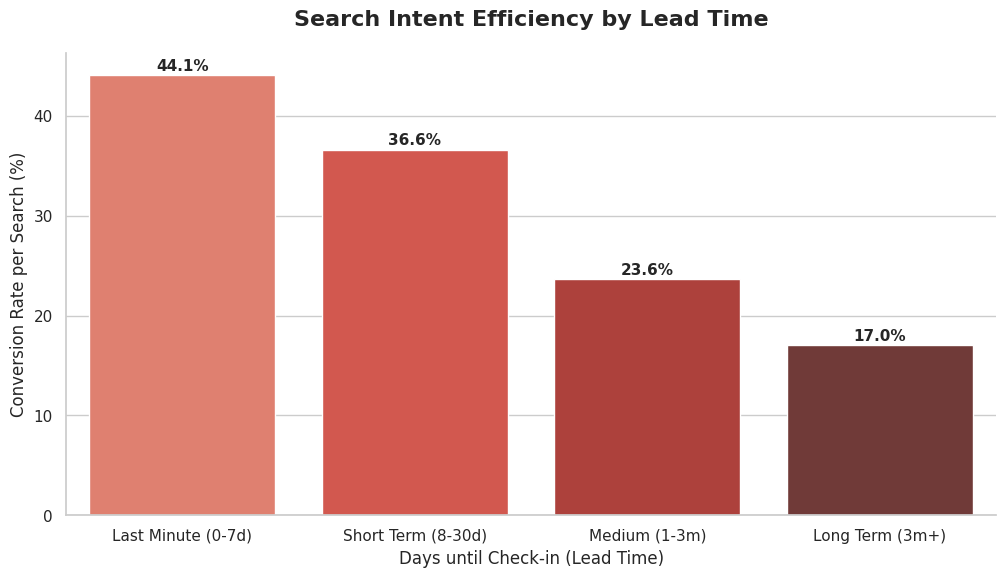


--- נתונים עבור Lead Time (סיכום שורות חיפוש) ---


,lead_time_bucket,Total_Searches,Converted_Searches,Conversion_Rate_Pct
0,Last Minute (0-7d),4861,2142,44.07
1,Short Term (8-30d),8514,3118,36.62
2,Medium (1-3m),6848,1619,23.64
3,Long Term (3m+),3660,624,17.05


In [ ]:
# 1. הגדרת עמודת המרה ברמת שורת חיפוש (כפי שביצענו בחישוב המקורי)
# משתמש שחיפש ומופיע בטבלת הפניות נחשב כמי שהמיר את החיפוש לפנייה
oct_searches['is_converted_session'] = oct_searches['id_user'].isin(contactors_set)

# 2. אגרגציה לפי Lead Time - ספירת שורות וחישוב ממוצע המרה
lead_time_summary = oct_searches.groupby('lead_time_bucket', observed=True).agg(
    Total_Searches=('is_converted_session', 'count'), # סך החיפושים (שורות) בקטגוריה
    Converted_Searches=('is_converted_session', 'sum'), # כמה מהחיפושים הללו הגיעו מיוזרים שפנו למארח
    Conversion_Rate_Pct=('is_converted_session', lambda x: x.mean() * 100) # אחוז ההמרה המדויק
).reset_index()

# 3. ויזואליזציה (גרף נפרד וגדול)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=lead_time_summary, x='lead_time_bucket', y='Conversion_Rate_Pct', palette='Reds_d')

plt.title('Search Intent Efficiency by Lead Time', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate per Search (%)', fontsize=12)
plt.xlabel('Days until Check-in (Lead Time)', fontsize=12)

# הוספת תוויות אחוזים מעל הברים
for i, v in enumerate(lead_time_summary['Conversion_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

sns.despine()
plt.show()

# 4. הצגת נתונים גולמיים להעתקה
print("\n--- נתונים עבור Lead Time (סיכום שורות חיפוש) ---")
display(lead_time_summary.round(2))

<div dir="rtl">

### 2ב. השפעת השימוש בפילטרים על "איכות החיפוש"
**מטרה:** לבחון האם חיפושים ממוקדים (הכוללים פילטר מחיר או סוג חדר) מעידים על כוונת רכישה גבוהה יותר מחיפושים כלליים.

**שיטת החישוב:**
* **הגדרה:** בדומה לממצא הקודם, החישוב מתבצע ברמת **שורת החיפוש**.
* **משמעות:** אנחנו בודקים מתוך כלל ה"סשנים" של החיפוש עם פילטרים, כמה מהם שייכים למשתמשים שהמירו לפנייה אקטיבית למארח.

**תובנה עסקית:**
שימוש בפילטרים הוא "סיגנל" חזק מאוד לרצינות המשתמש. משתמש שטורח להגדיר העדפות מדויקות נמצא עמוק יותר בתהליך ההחלטה מאשר משתמש שמבצע חיפוש גנרי.

</div>

/tmp/ipykernel_4262/3540738086.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=filter_summary, x='has_filter', y='Conversion_Rate_Pct', palette='Blues_d')


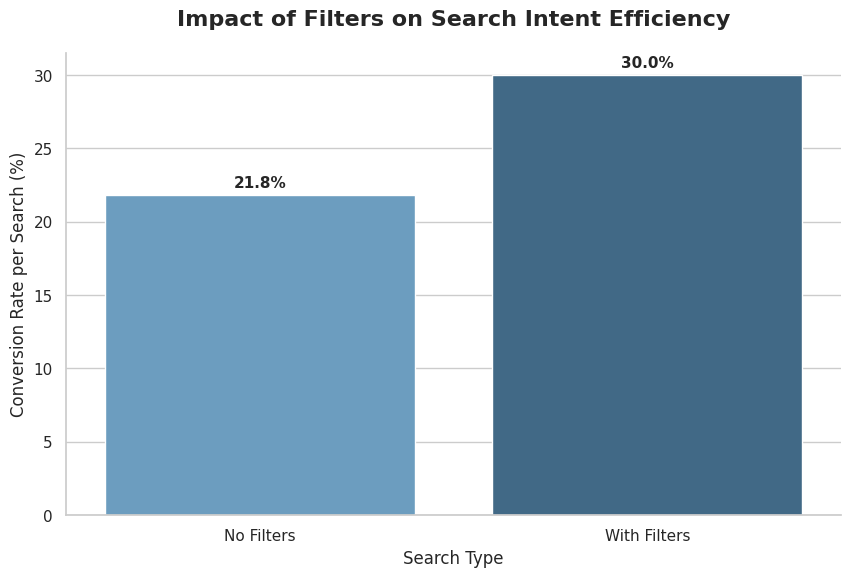


--- נתונים עבור שימוש בפילטרים (סיכום שורות חיפוש) ---


,has_filter,Total_Searches,Converted_Searches,Conversion_Rate_Pct
0,No Filters,14904,3251,21.81
1,With Filters,20833,6246,29.98


In [ ]:
# 1. אגרגציה לפי שימוש בפילטרים - ספירת שורות וחישוב ממוצע המרה
# עמודת 'has_filter' הוגדרה בשלב הקודם (With Filters / No Filters)
filter_summary = oct_searches.groupby('has_filter').agg(
    Total_Searches=('is_converted_session', 'count'), # סך החיפושים (שורות)
    Converted_Searches=('is_converted_session', 'sum'), # חיפושים של יוזרים שהמירו
    Conversion_Rate_Pct=('is_converted_session', lambda x: x.mean() * 100) # האחוז המדויק
).reset_index()

# 2. ויזואליזציה (גרף נפרד)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=filter_summary, x='has_filter', y='Conversion_Rate_Pct', palette='Blues_d')

plt.title('Impact of Filters on Search Intent Efficiency', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate per Search (%)', fontsize=12)
plt.xlabel('Search Type', fontsize=12)

# הוספת תוויות אחוזים מעל הברים
for i, v in enumerate(filter_summary['Conversion_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

sns.despine()
plt.show()

# 3. הצגת נתונים גולמיים להעתקה
print("\n--- נתונים עבור שימוש בפילטרים (סיכום שורות חיפוש) ---")
display(filter_summary.round(2))

<div dir="rtl">

### 2ג. הקשר בין נחישות המשתמש (Search Intensity) לבין המרה
**מטרה:** לבחון האם ריבוי חיפושים מעיד על משתמש "אבוד" שלא מוצא את מבוקשו, או על משתמש נחוש וממוקד שמחפש עד שמוצא את הדירה המתאימה.

**שיטת החישוב:**
* **הגדרה:** החישוב מתבצע ברמת ה**משתמש הייחודי**.
* **באקטים (Buckets):** חילקנו את המשתמשים לקבוצות לפי סך החיפושים שביצעו במהלך אוקטובר.
* **המדד (Conversion Rate %):** אחוז המשתמשים בכל קבוצה ששלחו לפחות הודעה אחת למארח.

**תובנה עסקית:**
ישנה קורלציה חיובית מובהקת: ככל שמשתמש משקיע יותר בחיפוש, כך הסיכוי שלו להמיר עולה דרמטית. משתמשים שביצעו מעל 50 חיפושים הם בעלי כוונת רכישה של מעל 50%, מה שמעיד על כך שהפלטפורמה מצליחה לספק תוצאות רלוונטיות גם למחפשים ה"קשים" ביותר.

</div>

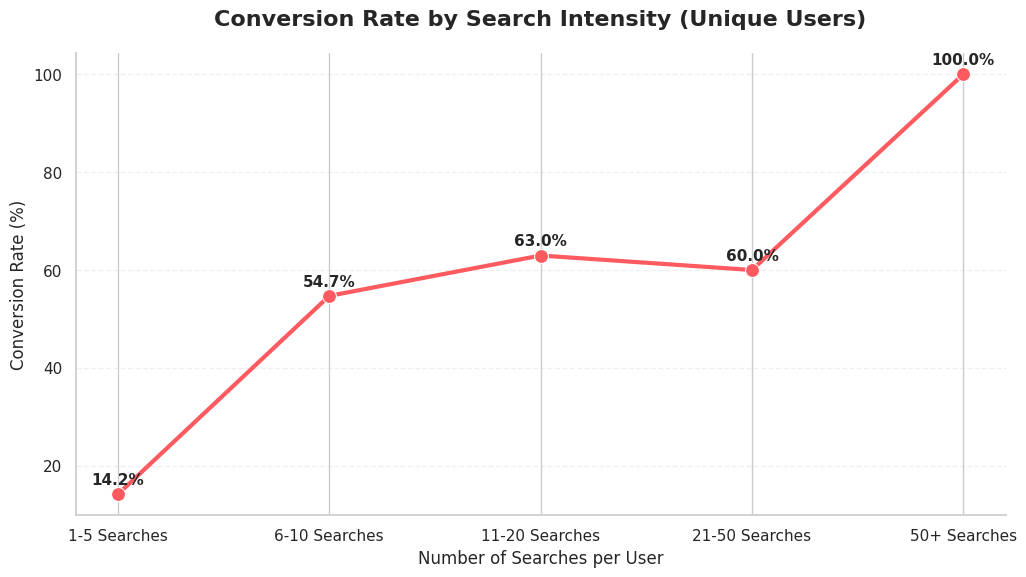


--- נתונים עבור נפח חיפושים (סיכום משתמשים ייחודיים) ---


,search_volume_bucket,Total_Users,Converted_Users,Conversion_Rate_Pct
0,1-5 Searches,17891,2537,14.18
1,6-10 Searches,594,325,54.71
2,11-20 Searches,108,68,62.96
3,21-50 Searches,10,6,60.00
4,50+ Searches,2,2,100.00


In [ ]:
# 1. הכנת נתונים - סיכום לפי משתמש (חישוב המרה וכמויות)
user_search_counts = oct_searches.groupby('id_user').size().reset_index(name='total_searches')
user_search_counts['search_volume_bucket'] = pd.cut(user_search_counts['total_searches'],
                                                  bins=[0, 5, 10, 20, 50, 1000],
                                                  labels=['1-5 Searches', '6-10 Searches', '11-20 Searches', '21-50 Searches', '50+ Searches'])

# בדיקה האם המשתמש המיר (נמצא ברשימת הפניות)
user_search_counts['is_converted'] = user_search_counts['id_user'].isin(contactors_set)

# 2. אגרגציה לפי באקט - ספירת משתמשים וחישוב המרה
volume_summary = user_search_counts.groupby('search_volume_bucket', observed=True).agg(
    Total_Users=('id_user', 'count'), # כמה משתמשים יש בבאקט הזה
    Converted_Users=('is_converted', 'sum'), # כמה מהם שלחו הודעה
    Conversion_Rate_Pct=('is_converted', lambda x: x.mean() * 100) # אחוז ההמרה המדויק
).reset_index()

# 3. ויזואליזציה (גרף קו להצגת מגמה)
plt.figure(figsize=(12, 6))
sns.lineplot(data=volume_summary, x='search_volume_bucket', y='Conversion_Rate_Pct',
             marker='o', linewidth=3, markersize=10, color='#FF5A5F')

plt.title('Conversion Rate by Search Intensity (Unique Users)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.xlabel('Number of Searches per User', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# הוספת תוויות אחוזים מעל הנקודות
for i, v in enumerate(volume_summary['Conversion_Rate_Pct']):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

sns.despine()
plt.show()

# 4. הצגת נתונים גולמיים להעתקה
print("\n--- נתונים עבור נפח חיפושים (סיכום משתמשים ייחודיים) ---")
display(volume_summary.round(2))

<div dir="rtl">

## 3. ניתוח פילוח גיאוגרפי (Origin Country Performance)
**מטרה:** השוואת ביצועי המרה והרגלי חיפוש בין מדינות המקור של המשתמשים (Guest Origin).

**שיטת החישוב (הגדרה):**
* **קהל היעד:** משתמשים ייחודיים (Unique Users) שבוצע עבורם זיהוי מדינה (Country Code).
* **מדד ההמרה (Conversion Rate %):** אחוז המשתמשים מכל מדינה שביצעו חיפוש ובסופו של דבר שלחו הודעה למארח.
* **מדד השימוש בפילטרים (Filter Usage %):** אחוז המשתמשים שהשתמשו לפחות פעם אחת בפילטר מחיר או סוג חדר.
* **מדד הנפח (Total Bookings):** סך ההזמנות הסופיות שבוצעו על ידי משתמשים מאותה מדינה.

**תובנות מרכזיות:**
1. **צרפת (FR) - המודל המנצח:** שוק יעיל מאוד. המשתמשים הצרפתים הם הממוקדים ביותר (75% שימוש בפילטרים), מה שמוביל לאחוז המרה גבוה (20.2%).
2. **ארה"ב (US) - מנוע הצמיחה:** המדינה שמייצרת את נפח ההזמנות הגדול ביותר (407 הזמנות), למרות אחוזי המרה ממוצעים.
3. **אירלנד (IE) - האנומליה המקומית:** שוק עם ביקוש אדיר (המון חיפושים) אך יעילות נמוכה (8.9%). נראה שהמשתמשים המקומיים משתמשים באתר ל"חיפוש כללי" ללא מיקוד בפילטרים.

</div>

/tmp/ipykernel_4262/3479000949.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=search_volume, x='origin_country', y='Total_Searches', palette='Greens_d')


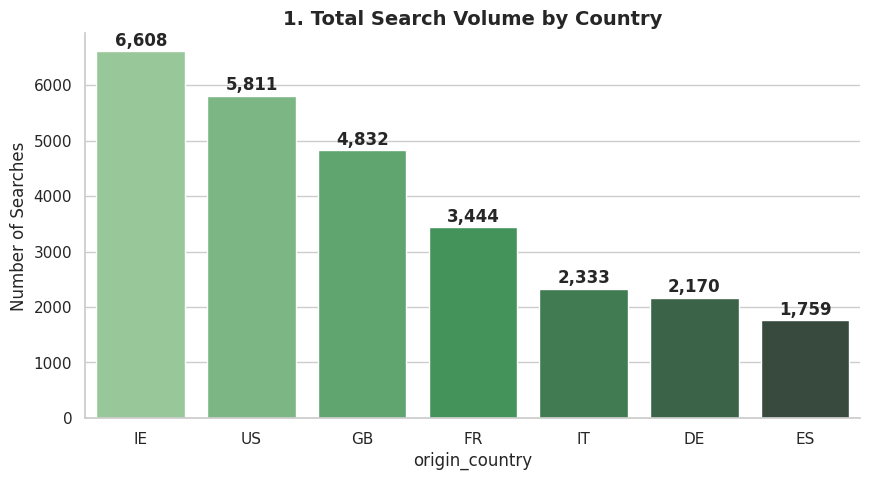


--- נתונים עבור כמות חיפושים ---


,origin_country,Total_Searches
4,IE,6608
6,US,5811
3,GB,4832
2,FR,3444
5,IT,2333
0,DE,2170
1,ES,1759


In [ ]:
# 1. חישוב כמות חיפושים (שורות) לפי מדינה
search_volume = oct_searches[oct_searches['origin_country'].isin(top_countries)].groupby('origin_country').size().reset_index(name='Total_Searches')
search_volume = search_volume.sort_values('Total_Searches', ascending=False)

# 2. גרף
plt.figure(figsize=(10, 5))
sns.barplot(data=search_volume, x='origin_country', y='Total_Searches', palette='Greens_d')
plt.title('1. Total Search Volume by Country', fontsize=14, fontweight='bold')
plt.ylabel('Number of Searches')

for i, v in enumerate(search_volume['Total_Searches']):
    plt.text(i, v + 100, f'{int(v):,}', ha='center', fontweight='bold')

sns.despine()
plt.show()

# 3. נתונים להעתקה
print("\n--- נתונים עבור כמות חיפושים ---")
display(search_volume)

/tmp/ipykernel_4262/1019792997.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_conv, x='origin_country', y='Conversion_Rate_Pct', palette='viridis')


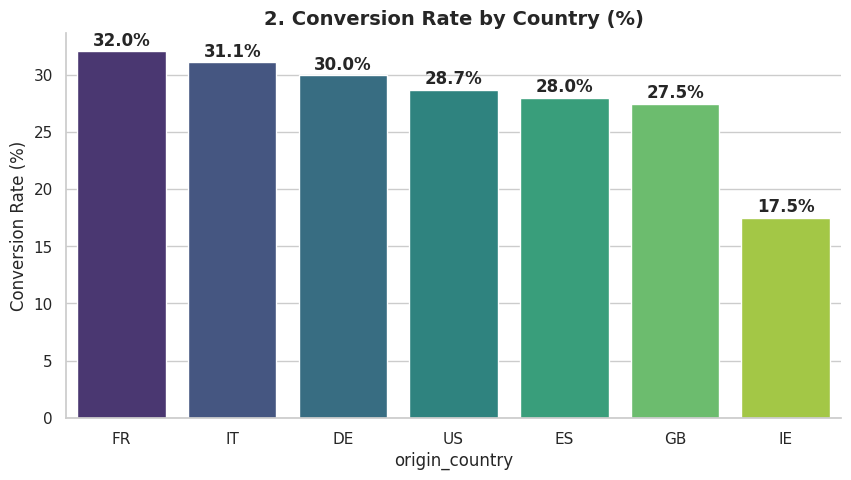


--- נתונים עבור אחוז המרה ---


,origin_country,Total_Searches,Converted_Searches,Conversion_Rate_Pct
2,FR,3444,1103,32.03
5,IT,2333,725,31.08
0,DE,2170,650,29.95
6,US,5811,1667,28.69
1,ES,1759,492,27.97
3,GB,4832,1327,27.46
4,IE,6608,1156,17.49


In [ ]:
# 1. חישוב אחוז המרה (מבוסס על ה-is_converted_session שיצרנו קודם)
geo_conv = oct_searches[oct_searches['origin_country'].isin(top_countries)].groupby('origin_country').agg(
    Total_Searches=('is_converted_session', 'count'),
    Converted_Searches=('is_converted_session', 'sum'),
    Conversion_Rate_Pct=('is_converted_session', lambda x: x.mean() * 100)
).reset_index().sort_values('Conversion_Rate_Pct', ascending=False)

# 2. גרף
plt.figure(figsize=(10, 5))
sns.barplot(data=geo_conv, x='origin_country', y='Conversion_Rate_Pct', palette='viridis')
plt.title('2. Conversion Rate by Country (%)', fontsize=14, fontweight='bold')
plt.ylabel('Conversion Rate (%)')

for i, v in enumerate(geo_conv['Conversion_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.show()

# 3. נתונים להעתקה
print("\n--- נתונים עבור אחוז המרה ---")
display(geo_conv.round(2))

/tmp/ipykernel_4262/2516586080.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_filters_summary, x='origin_country', y='Filter_Usage_Pct', palette='magma')


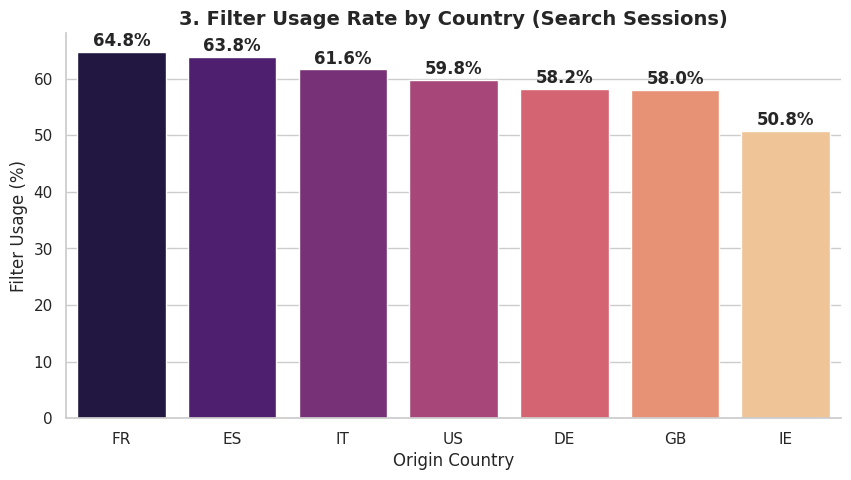


--- נתונים עבור שימוש בפילטרים (סיכום שורות חיפוש) ---


,origin_country,Total_Searches,Searches_With_Filters,Filter_Usage_Pct
2,FR,3444,2231,64.78
1,ES,1759,1123,63.84
5,IT,2333,1438,61.64
6,US,5811,3476,59.82
0,DE,2170,1264,58.25
3,GB,4832,2802,57.99
4,IE,6608,3355,50.77


In [ ]:
# 1. אגרגציה לפי מדינה - ספירת שורות חיפוש עם/בלי פילטרים
geo_filters_summary = oct_searches[oct_searches['origin_country'].isin(top_countries)].groupby('origin_country').agg(
    Total_Searches=('has_filter', 'count'), # סך כל החיפושים מהמדינה
    Searches_With_Filters=('has_filter', lambda x: (x == 'With Filters').sum()), # כמה חיפושים כללו פילטר
    Filter_Usage_Pct=('has_filter', lambda x: (x == 'With Filters').mean() * 100) # אחוז השימוש
).reset_index().sort_values('Filter_Usage_Pct', ascending=False)

# 2. ויזואליזציה
plt.figure(figsize=(10, 5))
sns.barplot(data=geo_filters_summary, x='origin_country', y='Filter_Usage_Pct', palette='magma')

plt.title('3. Filter Usage Rate by Country (Search Sessions)', fontsize=14, fontweight='bold')
plt.ylabel('Filter Usage (%)')
plt.xlabel('Origin Country')

# הוספת אחוזים מעל הברים
for i, v in enumerate(geo_filters_summary['Filter_Usage_Pct']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.show()

# 3. נתונים להעתקה (כולל הכמויות הגולמיות)
print("\n--- נתונים עבור שימוש בפילטרים (סיכום שורות חיפוש) ---")
display(geo_filters_summary.round(2))

<div dir="rtl">

## 4. ניתוח התאמת המלאי (Inventory Fit)
**מטרה:** לבחון האם אחוז ההמרה משתנה בהתאם לגודל הקבוצה (מספר האורחים), כדי לזהות חוסר במלאי רלוונטי.

**שיטת החישוב:**
* **הגדרה:** החישוב מתבצע ברמת **שורת החיפוש** (Search Session).
* **חלוקה לקטגוריות:** חילקנו את החיפושים לפי מספר האורחים המבוקש (`n_guests`).
* **המדד (Conversion Rate %):** אחוז החיפושים בכל קטגוריה שהובילו לפנייה למארח.

**תובנה עסקית:**
אם נזהה צניחה באחוזי ההמרה בקבוצות גדולות (למשל 5+ אורחים) למרות שיש הרבה חיפושים כאלו, המשמעות היא שהמלאי בדבלין מוטה לדירות קטנות מדי ושחסרות "דירות משפחתיות".

</div>

/tmp/ipykernel_4262/3520949135.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inventory_stats, x='guest_bucket', y='Conversion_Rate_Pct', palette='YlOrBr')


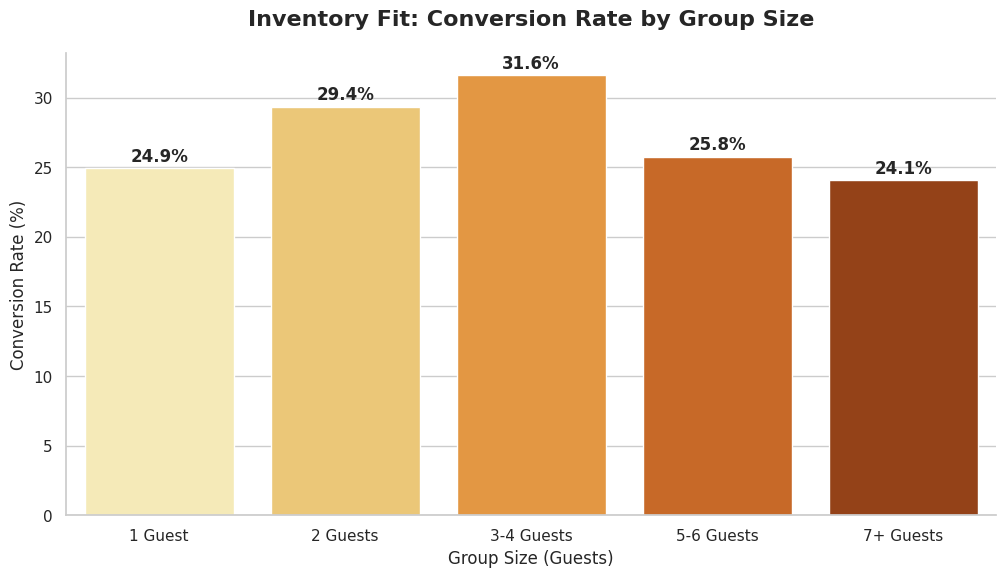


--- נתונים עבור התאמת מלאי (כולל כמויות) ---


,guest_bucket,Total_Searches,Converted_Searches,Conversion_Rate_Pct
0,1 Guest,22573,5626,24.92
1,2 Guests,8001,2349,29.36
2,3-4 Guests,3455,1092,31.61
3,5-6 Guests,1110,286,25.77
4,7+ Guests,598,144,24.08


In [ ]:
# 1. בדיקת שם העמודה וחלוקה לבאקטים (משתמשים ב-n_guests_min)
# אם העמודה נקראת אחרת אצלך, פשוט החלף את 'n_guests_min' בשם הנכון
guest_col = 'n_guests_min'

oct_searches['guest_bucket'] = pd.cut(oct_searches[guest_col],
                                     bins=[0, 1, 2, 4, 6, 20],
                                     labels=['1 Guest', '2 Guests', '3-4 Guests', '5-6 Guests', '7+ Guests'])

# 2. אגרגציה - חישוב המרה וכמויות (מבוסס על is_converted_session ששמרנו קודם)
inventory_stats = oct_searches.groupby('guest_bucket', observed=True).agg(
    Total_Searches=('is_converted_session', 'count'),
    Converted_Searches=('is_converted_session', 'sum'),
    Conversion_Rate_Pct=('is_converted_session', lambda x: x.mean() * 100)
).reset_index()

# 3. ויזואליזציה
plt.figure(figsize=(12, 6))
sns.barplot(data=inventory_stats, x='guest_bucket', y='Conversion_Rate_Pct', palette='YlOrBr')

plt.title('Inventory Fit: Conversion Rate by Group Size', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Group Size (Guests)')

# הוספת אחוזים מעל הברים
for i, v in enumerate(inventory_stats['Conversion_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.show()

# 4. נתונים להעתקה
print("\n--- נתונים עבור התאמת מלאי (כולל כמויות) ---")
display(inventory_stats.round(2))

<div dir="rtl">

## 5א. הקשר בין עומק השיחה לסיכויי סגירה
**מטרה:** לבחון האם ריבוי הודעות בין האורח למארח מעיד על תהליך בניית אמון שמוביל להזמנה סגורה.

**שיטת החישוב:**
* **הגדרה:** פילוח כל הפניות (Inquiries) לפי מספר ההודעות הכולל בשרשור (`n_messages`).
* **המדד (Booking Rate %):** אחוז הפניות בכל קטגוריה שהפכו להזמנה מאושרת (`is_booked`).

**תובנה עסקית:**
שיחות קצרות (1-2 הודעות) לרוב מסתיימות ללא עסקה. לעומת זאת, ככל שהשיח מתפתח (6+ הודעות), עולה הוודאות של האורח והאמון במארח, מה שמקפיץ את אחוזי הסגירה. זהו "הגורם האנושי" שמכריע את המכירה.

</div>

/tmp/ipykernel_4262/1963133861.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oct_contacts['msg_bucket'] = pd.cut(oct_contacts['n_messages'],
/tmp/ipykernel_4262/1963133861.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=human_msg_stats, x='msg_bucket', y='Booking_Rate_Pct', palette='coolwarm')


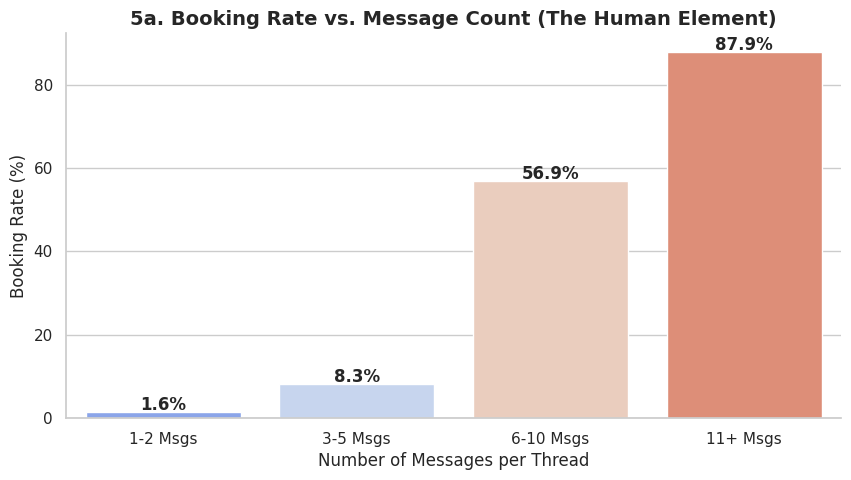


--- נתונים עבור כמות הודעות (n_messages) ---


,msg_bucket,Total_Inquiries,Total_Bookings,Booking_Rate_Pct
0,1-2 Msgs,1564,25,1.60
1,3-5 Msgs,2537,210,8.28
2,6-10 Msgs,1251,712,56.91
3,11+ Msgs,1108,974,87.91


In [ ]:
# 1. יצירת באקטים לכמות הודעות (n_messages)
oct_contacts['msg_bucket'] = pd.cut(oct_contacts['n_messages'],
                                   bins=[-1, 2, 5, 10, 500],
                                   labels=['1-2 Msgs', '3-5 Msgs', '6-10 Msgs', '11+ Msgs'])

# 2. אגרגציה - חישוב אחוז סגירה (Booking Rate) וכמויות
human_msg_stats = oct_contacts.groupby('msg_bucket', observed=True).agg(
    Total_Inquiries=('is_booked', 'count'), # סך הפניות בקטגוריה
    Total_Bookings=('is_booked', 'sum'),    # כמה מהן נסגרו כהזמנה
    Booking_Rate_Pct=('is_booked', lambda x: x.mean() * 100) # אחוז הסגירה
).reset_index()

# 3. ויזואליזציה
plt.figure(figsize=(10, 5))
sns.barplot(data=human_msg_stats, x='msg_bucket', y='Booking_Rate_Pct', palette='coolwarm')

plt.title('5a. Booking Rate vs. Message Count (The Human Element)', fontsize=14, fontweight='bold')
plt.ylabel('Booking Rate (%)')
plt.xlabel('Number of Messages per Thread')

# הוספת אחוזים מעל הברים
for i, v in enumerate(human_msg_stats['Booking_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.show()

# 4. נתונים להעתקה
print("\n--- נתונים עבור כמות הודעות (n_messages) ---")
display(human_msg_stats.round(2))

<div dir="rtl">

## 5ב. מבחן המענה המהיר: זמן תגובת המארח
**מטרה:** לבחון עד כמה מהירות המענה של המארח (בדקות ושעות) קריטית להמרת פנייה להזמנה בפועל.

**שיטת החישוב:**
* **הגדרה:** שימוש במדד המובנה `reply_time_minutes` לחלוקת המארחים לקבוצות איכות (ממענה מיידי ועד מענה מעל יממה).
* **המדד (Booking Rate %):** אחוז הפניות שנסגרו כהזמנה בכל טווח זמן.

**תובנה עסקית:**
בשוק תחרותי כמו Airbnb, המומנטום הוא הכל. אורח ששולח פנייה נמצא לרוב "בתוך האירוע". מענה מהיר (במיוחד בטווח של עד 15-60 דקות) תופס את האורח כשהוא זמין ומוכן לסגור, בעוד שעיכוב של מעל 4 שעות גורם לאובדן עניין או פנייה למתחרים.

</div>

/tmp/ipykernel_4262/648479561.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oct_contacts['reply_bucket'] = pd.cut(oct_contacts['reply_time_minutes'],
/tmp/ipykernel_4262/648479561.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=human_reply_stats, x='reply_bucket', y='Booking_Rate_Pct', palette='YlGnBu')


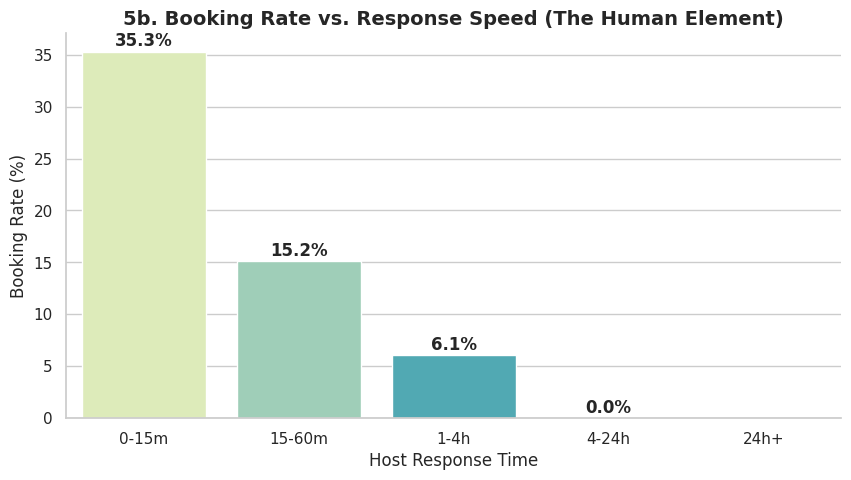


--- נתונים עבור זמן תגובה (reply_time_minutes) ---


,reply_bucket,Total_Inquiries,Total_Bookings,Booking_Rate_Pct
0,0-15m,5111,1804,35.30
1,15-60m,719,109,15.16
2,1-4h,131,8,6.11
3,4-24h,11,0,0.00


In [ ]:
# 1. יצירת באקטים לזמן תגובה (reply_time_minutes)
# חלוקה מזמנים מיידיים (דקות) ועד יממה פלוס
oct_contacts['reply_bucket'] = pd.cut(oct_contacts['reply_time_minutes'],
                                     bins=[-1, 15, 60, 240, 1440, 100000],
                                     labels=['0-15m', '15-60m', '1-4h', '4-24h', '24h+'])

# 2. אגרגציה - חישוב אחוז סגירה וכמויות
human_reply_stats = oct_contacts.groupby('reply_bucket', observed=True).agg(
    Total_Inquiries=('is_booked', 'count'),
    Total_Bookings=('is_booked', 'sum'),
    Booking_Rate_Pct=('is_booked', lambda x: x.mean() * 100)
).reset_index()

# 3. ויזואליזציה
plt.figure(figsize=(10, 5))
sns.barplot(data=human_reply_stats, x='reply_bucket', y='Booking_Rate_Pct', palette='YlGnBu')

plt.title('5b. Booking Rate vs. Response Speed (The Human Element)', fontsize=14, fontweight='bold')
plt.ylabel('Booking Rate (%)')
plt.xlabel('Host Response Time')

# הוספת אחוזים מעל הברים
for i, v in enumerate(human_reply_stats['Booking_Rate_Pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

sns.despine()
plt.show()

# 4. נתונים להעתקה
print("\n--- נתונים עבור זמן תגובה (reply_time_minutes) ---")
display(human_reply_stats.round(2))